# TDMA Multi-User Search Notebook

This notebook uses `src/multi_user_tdma_study` for exact multi-user TDMA candidate generation.
The notebook then moves to a separate joint-scheduler section that consumes those prepared user spaces.


## 1. Imports


In [1]:
import os
import sys
from pathlib import Path

import matplotlib
import matplotlib.pyplot as plt
from matplotlib import colors, patches
from mpl_toolkits.mplot3d.art3d import Poly3DCollection
matplotlib.use("Agg")
%matplotlib inline

import numpy as np
import pandas as pd
from IPython.display import display
sys.path.insert(0, str((Path.cwd() / "src").resolve()))

NOTEBOOK_OUTER_PARALLEL = True
NOTEBOOK_MAX_WORKERS = max(1, os.cpu_count() or 1)

from radio_core import MULTI_USER_TDMA_PRESET, PAState, PASwitchPolicy, inactive_pa_bank_power
from multi_user_tdma_study import build_multi_user_tdma_scenario, run_multi_user_tdma_scenario, summarize_multi_user_tdma_scenario

## 2. Explicit Scenario Inputs

The notebook fixes one multi-user rate request table and hands it to `multi_user_tdma_study`. The module owns the shared system view, active operating catalogs, repeated-frame resolution, and exact per-user TDMA candidate spaces.

In [2]:
users = [
    dict(user_id=1, distance_m=100.0, required_rate_bps=300e6),
    dict(user_id=2, distance_m=150.0, required_rate_bps=40e6),
    dict(user_id=3, distance_m=200.0, required_rate_bps=50e6),
    dict(user_id=4, distance_m=250.0, required_rate_bps=20e6),
    dict(user_id=5, distance_m=500.0, required_rate_bps=10e6),
]

user_table = pd.DataFrame(users).sort_values("user_id").reset_index(drop=True)
switch_policy = MULTI_USER_TDMA_PRESET.runtime.switch_policy
scenario = build_multi_user_tdma_scenario(user_table)
scenario_views = summarize_multi_user_tdma_scenario(scenario)
study_result = run_multi_user_tdma_scenario(scenario, outer_parallel=NOTEBOOK_OUTER_PARALLEL, max_workers=NOTEBOOK_MAX_WORKERS)
system_cfg = scenario.system_cfg
pa_catalog = scenario.pa_catalog
study_summary = pd.DataFrame([{"n_users": int(len(user_table)), "frame_slots": int(system_cfg["frame_slots"]), "repeated_frames": int(study_result.repeated_frames), "repeated_period_slots": int(study_result.repeated_period_slots), "switch_policy": switch_policy.value}])
display(user_table)
display(study_summary)

,user_id,distance_m,required_rate_bps
0,1,100.0,300000000.0
1,2,150.0,40000000.0
2,3,200.0,50000000.0
3,4,250.0,20000000.0
4,5,500.0,10000000.0


,n_users,frame_slots,repeated_frames,repeated_period_slots,switch_policy
0,5,20,1,20,standby


## 3. Prepared Module Views

In [3]:
display(scenario_views["system_summary"])
display(scenario_views["active_search_summary"])
display(scenario_views["pa_characteristics"])

,n_users,window_slots,slot_duration_ms,window_duration_ms
0,5,20,0.5,10.0


,bandwidth_space_hz,window_slots,prb_step
0,"(100000000.0, 50000000.0)","(20,)",5


,pa_id,pa_name,source_csv,n_curve_points,p_max_w,p_idle_w,eta_max,g_pa_eff_linear,g_pa_eff_db,kappa_distortion,backoff_db
0,0,Bae et al. NR,PA models\3.5Ghz_pas\4W_8W_NR_combined_NR_carr...,64,7.928899,5.239623,0.418165,1817.545759,32.594854,0.08,6.0
1,1,QPA9942,PA models\3.5Ghz_pas\4W_8W_NR_combined_NR_carr...,64,1.784671,0.641172,0.352236,935.848316,29.712055,0.08,6.0


## 4. Exact Per-User TDMA Candidate Generation from `multi_user_tdma_study`


In [4]:
review_user_id = int(user_table["user_id"].iloc[1])

print("Active operating-point summary")
display(study_result.active_summary_df)
print("Frame-share lower bounds")
display(study_result.frame_share_summary_df)
print("Per-user TDMA candidate-space summary")
display(study_result.user_candidate_summary_df)

candidate_preview = (
    pd.concat(
        [
            review_table.head(3)
            for _, review_table in sorted(study_result.user_candidate_review_tables.items())
        ],
        ignore_index=True,
    )
    .sort_values(["user_id", "candidate_rank"])
    .reset_index(drop=True)
)
print("Compact candidate preview (top 3 rows per user)")
display(candidate_preview)

print(f"Detailed compact candidate view for user {review_user_id}")
display(study_result.user_candidate_review_tables[review_user_id].head(10))


Active operating-point summary


,user_id,distance_m,path_loss_db,required_rate_bps,active_operating_points,max_active_rate_mbps,min_active_power_w
0,1,100.0,108.643832,300000000.0,48688,1177.418650,2.564688
1,2,150.0,114.829245,40000000.0,47479,1130.213376,2.564688
2,3,200.0,119.228841,50000000.0,44845,892.999987,2.564688
3,4,250.0,122.644788,20000000.0,41029,704.221286,2.564688
4,5,500.0,133.264505,10000000.0,22720,224.799053,2.564688


Frame-share lower bounds


,user_id,required_rate_bps,max_active_rate_bps,exact_frame_share_lb
0,1,300000000.0,1.177419e+09,0.254795
1,2,40000000.0,1.130213e+09,0.035392
2,3,50000000.0,8.930000e+08,0.055991
3,4,20000000.0,7.042213e+08,0.028400
4,5,10000000.0,2.247991e+08,0.044484


Per-user TDMA candidate-space summary


,user_id,distance_m,path_loss_db,required_rate_bps,repeated_period_slots,configs_raw,configs_pruned,min_slots,max_slots
0,1,100.0,108.643832,300000000.0,20,3942,58,6,12
1,2,150.0,114.829245,40000000.0,20,27389,101,1,4
2,3,200.0,119.228841,50000000.0,20,22025,108,2,7
3,4,250.0,122.644788,20000000.0,20,28665,128,1,5
4,5,500.0,133.264505,10000000.0,20,16366,86,1,4


Compact candidate preview (top 3 rows per user)


,candidate_rank,user_id,distance_m,path_loss_db,n_slots,n_prb,mcs,rank,pa_name,required_rate_mbps,achieved_rate_mbps,rate_margin_mbps,p_dc_active_w,p_dc_avg_frame_w
0,1,1,100.0,108.643832,6,271,25,4,QPA9942,300.0,300.728310,0.728310,13.488141,4.046442
1,2,1,100.0,108.643832,6,276,25,4,QPA9942,300.0,306.276803,6.276803,13.665668,4.099700
2,3,1,100.0,108.643832,6,261,26,4,QPA9942,300.0,307.599483,7.599483,14.954680,4.486404
3,1,2,150.0,114.829245,1,271,22,4,Bae et al. NR,40.0,40.608895,0.608895,34.928642,1.746432
4,2,2,150.0,114.829245,1,276,22,4,Bae et al. NR,40.0,41.358136,1.358136,35.230059,1.761503
5,3,2,150.0,114.829245,1,256,23,4,Bae et al. NR,40.0,41.414492,1.414492,38.446878,1.922344
6,1,3,200.0,119.228841,2,271,15,4,QPA9942,50.0,50.081841,0.081841,18.276896,1.827690
7,2,3,200.0,119.228841,2,276,15,4,QPA9942,50.0,51.005860,1.005860,18.544998,1.854500
8,3,3,200.0,119.228841,2,261,17,4,QPA9942,50.0,51.442975,1.442975,19.018237,1.901824
9,1,4,250.0,122.644788,1,276,13,4,Bae et al. NR,20.0,20.286397,0.286397,34.700803,1.735040


Detailed compact candidate view for user 2


,candidate_rank,user_id,distance_m,path_loss_db,n_slots,n_prb,mcs,rank,pa_name,required_rate_mbps,achieved_rate_mbps,rate_margin_mbps,p_dc_active_w,p_dc_avg_frame_w
0,1,2,150.0,114.829245,1,271,22,4,Bae et al. NR,40.0,40.608895,0.608895,34.928642,1.746432
1,2,2,150.0,114.829245,1,276,22,4,Bae et al. NR,40.0,41.358136,1.358136,35.230059,1.761503
2,3,2,150.0,114.829245,1,256,23,4,Bae et al. NR,40.0,41.414492,1.414492,38.446878,1.922344
3,4,2,150.0,114.829245,1,261,23,4,Bae et al. NR,40.0,42.223369,2.223369,38.856606,1.942830
4,5,2,150.0,114.829245,1,266,23,4,Bae et al. NR,40.0,43.032246,3.032246,39.266472,1.963324
5,6,2,150.0,114.829245,1,271,23,4,Bae et al. NR,40.0,43.841123,3.841123,39.676337,1.983817
6,7,2,150.0,114.829245,1,276,23,4,Bae et al. NR,40.0,44.649999,4.649999,40.086203,2.004310
7,8,2,150.0,114.829245,1,261,24,4,Bae et al. NR,40.0,45.335324,5.335324,42.079296,2.103965
8,9,2,150.0,114.829245,1,266,24,4,Bae et al. NR,40.0,46.203817,6.203817,42.381347,2.119067
9,10,2,150.0,114.829245,1,271,24,4,Bae et al. NR,40.0,47.072310,7.072310,42.683398,2.134170


## 5. TDMA Scheduler Helpers


In [5]:
# Joint scheduler helpers that remain notebook-local.

def _coerce_switch_policy(switch_policy):
    if isinstance(switch_policy, PASwitchPolicy):
        return switch_policy
    return PASwitchPolicy(str(switch_policy))


def row_active_frame_share(row):
    if "alpha_frame" in row:
        return float(row["alpha_frame"])
    return float(row["n_slots"]) / float(row["repeated_period_slots"])


def row_rate_avg_frame_bps(row):
    if "rate_avg_frame_bps" in row:
        return float(row["rate_avg_frame_bps"])
    return row_active_frame_share(row) * float(row["rate_active_bps"])


def row_p_dc_avg_frame_w(row):
    if "p_dc_avg_frame_w" in row:
        return float(row["p_dc_avg_frame_w"])
    return row_active_frame_share(row) * float(row["p_dc_active_w"])


def row_p_rf_out_avg_frame_w(row):
    if "p_rf_out_avg_frame_w" in row:
        return float(row["p_rf_out_avg_frame_w"])
    return row_active_frame_share(row) * float(row["p_rf_out_active_w"])


def row_incremental_schedule_cost(row, used_pa_ids, pa_catalog, n_tx_chains, switch_policy):
    switch_policy = _coerce_switch_policy(switch_policy)
    active_cost = row_p_dc_avg_frame_w(row)
    if switch_policy == PASwitchPolicy.HARD_OFF:
        return float(active_cost)

    pa_id = int(row["pa_id"])
    idle_bank_w = float(inactive_pa_bank_power(pa_catalog[pa_id], PAState.IDLE, n_tx_chains))
    incremental_cost = active_cost - row_active_frame_share(row) * idle_bank_w
    if pa_id not in used_pa_ids:
        incremental_cost += idle_bank_w
    return float(incremental_cost)


def row_schedule_sort_cost(row, pa_catalog, n_tx_chains, switch_policy):
    return row_incremental_schedule_cost(
        row,
        used_pa_ids=frozenset(),
        pa_catalog=pa_catalog,
        n_tx_chains=n_tx_chains,
        switch_policy=switch_policy,
    )


def schedule_rank(schedule_p_dc_total_avg_frame_w, slot_total, total_rate_bps):
    return (float(schedule_p_dc_total_avg_frame_w), int(slot_total), -float(total_rate_bps))


def evaluate_schedule_rows(selected_rows, repeated_period_slots, pa_catalog, n_tx_chains, switch_policy):
    switch_policy = _coerce_switch_policy(switch_policy)
    inactive_state = PAState.IDLE if switch_policy == PASwitchPolicy.STANDBY else PAState.OFF

    slot_total = int(sum(int(row["n_slots"]) for row in selected_rows))
    alpha_total_frame = float(slot_total) / float(repeated_period_slots)
    total_rate_bps = float(sum(row_rate_avg_frame_bps(row) for row in selected_rows))
    schedule_p_rf_out_total_avg_frame_w = float(sum(row_p_rf_out_avg_frame_w(row) for row in selected_rows))

    pa_summaries = []
    schedule_p_dc_total_avg_frame_w = 0.0
    used_pa_ids = sorted({int(row["pa_id"]) for row in selected_rows})
    for pa_id in used_pa_ids:
        pa_rows = [row for row in selected_rows if int(row["pa_id"]) == pa_id]
        pa_alpha_frame = float(np.clip(sum(row_active_frame_share(row) for row in pa_rows), 0.0, 1.0))
        pa_p_dc_active_avg_frame_w = float(sum(row_p_dc_avg_frame_w(row) for row in pa_rows))
        inactive_bank_w = float(inactive_pa_bank_power(pa_catalog[pa_id], inactive_state, n_tx_chains))
        pa_p_dc_inactive_avg_frame_w = float((1.0 - pa_alpha_frame) * inactive_bank_w)
        pa_p_dc_total_avg_frame_w = float(pa_p_dc_active_avg_frame_w + pa_p_dc_inactive_avg_frame_w)
        schedule_p_dc_total_avg_frame_w += pa_p_dc_total_avg_frame_w
        pa_summaries.append(
            {
                "pa_id": int(pa_id),
                "pa_name": str(pa_rows[0]["pa_name"]),
                "pa_alpha_frame": float(pa_alpha_frame),
                "pa_inactive_state": inactive_state.value,
                "pa_p_dc_active_avg_frame_w": float(pa_p_dc_active_avg_frame_w),
                "pa_p_dc_inactive_avg_frame_w": float(pa_p_dc_inactive_avg_frame_w),
                "pa_p_dc_total_avg_frame_w": float(pa_p_dc_total_avg_frame_w),
            }
        )

    return {
        "rows": sorted([dict(row) for row in selected_rows], key=lambda row: int(row["user_id"])),
        "slot_total": int(slot_total),
        "alpha_total_frame": float(alpha_total_frame),
        "unused_slots": int(repeated_period_slots - slot_total),
        "unused_frame_time": float(1.0 - alpha_total_frame),
        "total_rate_bps": float(total_rate_bps),
        "schedule_p_dc_total_avg_frame_w": float(schedule_p_dc_total_avg_frame_w),
        "schedule_p_rf_out_total_avg_frame_w": float(schedule_p_rf_out_total_avg_frame_w),
        "pa_summaries": pa_summaries,
        "switch_policy": switch_policy.value,
    }


In [6]:
def _joint_candidate_row(schedule_result, schedule_id):
    return {
        "schedule_id": int(schedule_id),
        "slot_total": int(schedule_result["slot_total"]),
        "alpha_total_frame": float(schedule_result["alpha_total_frame"]),
        "unused_slots": int(schedule_result["unused_slots"]),
        "unused_frame_time": float(schedule_result["unused_frame_time"]),
        "total_rate_bps": float(schedule_result["total_rate_bps"]),
        "schedule_p_dc_total_avg_frame_w": float(schedule_result["schedule_p_dc_total_avg_frame_w"]),
        "schedule_p_rf_out_total_avg_frame_w": float(schedule_result["schedule_p_rf_out_total_avg_frame_w"]),
        "switch_policy": str(schedule_result["switch_policy"]),
    }


def _rank_user_rows(candidate_table, pa_catalog, n_tx_chains, switch_policy):
    rows = candidate_table.to_dict("records")
    return sorted(
        rows,
        key=lambda row: (
            row_schedule_sort_cost(row, pa_catalog, n_tx_chains, switch_policy),
            int(row["n_slots"]),
            row_p_dc_avg_frame_w(row),
            -row_rate_avg_frame_bps(row),
        ),
    )


def search_joint_schedules(
    user_candidate_spaces,
    repeated_period_slots,
    pa_catalog,
    n_tx_chains,
    switch_policy=PASwitchPolicy.STANDBY,
):
    tol = 1e-12
    repeated_period_slots = int(repeated_period_slots)
    switch_policy = _coerce_switch_policy(switch_policy)

    ranked_user_rows = {
        int(user_id): _rank_user_rows(candidate_table, pa_catalog, n_tx_chains, switch_policy)
        for user_id, candidate_table in user_candidate_spaces.items()
    }
    min_slots = {
        user_id: min(int(row["n_slots"]) for row in rows)
        for user_id, rows in ranked_user_rows.items()
    }
    min_sort_cost = {
        user_id: min(
            row_schedule_sort_cost(row, pa_catalog, n_tx_chains, switch_policy)
            for row in rows
        )
        for user_id, rows in ranked_user_rows.items()
    }
    max_rate_avg_frame_bps = {
        user_id: max(row_rate_avg_frame_bps(row) for row in rows)
        for user_id, rows in ranked_user_rows.items()
    }

    user_order = sorted(
        ranked_user_rows,
        key=lambda user_id: (min_slots[user_id], min_sort_cost[user_id]),
        reverse=True,
    )

    suffix_min_slots = [0] * (len(user_order) + 1)
    suffix_max_rate_avg_frame_bps = [0.0] * (len(user_order) + 1)
    for depth in range(len(user_order) - 1, -1, -1):
        user_id = user_order[depth]
        suffix_min_slots[depth] = suffix_min_slots[depth + 1] + min_slots[user_id]
        suffix_max_rate_avg_frame_bps[depth] = (
            suffix_max_rate_avg_frame_bps[depth + 1] + max_rate_avg_frame_bps[user_id]
        )

    search_stats = {
        "user_order": list(user_order),
        "nodes_visited": 0,
        "complete_feasible_schedules": 0,
        "pruned_time_direct": 0,
        "pruned_power_direct": 0,
        "pruned_time_bound": 0,
        "pruned_power_bound": 0,
        "pruned_rank_bound": 0,
        "best_updates": 0,
    }
    joint_candidates = []
    best_rank = (np.inf, np.inf, np.inf)
    best_schedule_power = np.inf
    best_schedule = None
    lower_bound_cache = {}

    def remaining_cost_lower_bound(depth, used_pa_ids):
        if depth >= len(user_order):
            return 0.0

        key = (int(depth), tuple(sorted(int(pa_id) for pa_id in used_pa_ids)))
        cached = lower_bound_cache.get(key)
        if cached is not None:
            return cached

        user_id = user_order[depth]
        best_remaining_cost = np.inf
        for row in ranked_user_rows[user_id]:
            next_used_pa_ids = frozenset(set(used_pa_ids) | {int(row["pa_id"])} )
            candidate_cost = row_incremental_schedule_cost(
                row,
                used_pa_ids=used_pa_ids,
                pa_catalog=pa_catalog,
                n_tx_chains=n_tx_chains,
                switch_policy=switch_policy,
            ) + remaining_cost_lower_bound(depth + 1, next_used_pa_ids)
            if candidate_cost < best_remaining_cost:
                best_remaining_cost = candidate_cost

        lower_bound_cache[key] = float(best_remaining_cost)
        return float(best_remaining_cost)

    def seed_greedy_schedule():
        slot_sum = 0
        selected_rows = []
        used_pa_ids = frozenset()
        for depth, user_id in enumerate(user_order):
            remaining_slots_lb = suffix_min_slots[depth + 1]
            selected_row = None
            for row in ranked_user_rows[user_id]:
                next_slot_sum = int(slot_sum + int(row["n_slots"]))
                if next_slot_sum + remaining_slots_lb <= repeated_period_slots:
                    selected_row = row
                    slot_sum = next_slot_sum
                    selected_rows.append(row)
                    used_pa_ids = frozenset(set(used_pa_ids) | {int(row["pa_id"])} )
                    break
            if selected_row is None:
                return None

        return evaluate_schedule_rows(
            selected_rows=selected_rows,
            repeated_period_slots=repeated_period_slots,
            pa_catalog=pa_catalog,
            n_tx_chains=n_tx_chains,
            switch_policy=switch_policy,
        )

    def dfs(depth, slot_sum, exact_cost_sum, rate_sum, used_pa_ids, selected_rows):
        nonlocal best_rank, best_schedule_power, best_schedule

        search_stats["nodes_visited"] += 1

        if depth == len(user_order):
            schedule_result = evaluate_schedule_rows(
                selected_rows=selected_rows,
                repeated_period_slots=repeated_period_slots,
                pa_catalog=pa_catalog,
                n_tx_chains=n_tx_chains,
                switch_policy=switch_policy,
            )
            schedule_id = len(joint_candidates) + 1
            joint_candidates.append(_joint_candidate_row(schedule_result, schedule_id=schedule_id))
            search_stats["complete_feasible_schedules"] += 1

            candidate_rank = schedule_rank(
                schedule_result["schedule_p_dc_total_avg_frame_w"],
                schedule_result["slot_total"],
                schedule_result["total_rate_bps"],
            )
            if candidate_rank < best_rank:
                best_rank = candidate_rank
                best_schedule_power = float(schedule_result["schedule_p_dc_total_avg_frame_w"])
                best_schedule = schedule_result
                search_stats["best_updates"] += 1
            return

        user_id = user_order[depth]
        for row in ranked_user_rows[user_id]:
            next_slot_sum = int(slot_sum + int(row["n_slots"]))
            if next_slot_sum > repeated_period_slots:
                search_stats["pruned_time_direct"] += 1
                continue

            next_exact_cost_sum = float(
                exact_cost_sum
                + row_incremental_schedule_cost(
                    row,
                    used_pa_ids=used_pa_ids,
                    pa_catalog=pa_catalog,
                    n_tx_chains=n_tx_chains,
                    switch_policy=switch_policy,
                )
            )
            if next_exact_cost_sum > best_schedule_power + tol:
                search_stats["pruned_power_direct"] += 1
                continue

            remaining_slots_lb = suffix_min_slots[depth + 1]
            if next_slot_sum + remaining_slots_lb > repeated_period_slots:
                search_stats["pruned_time_bound"] += 1
                continue

            next_rate_sum = float(rate_sum + row_rate_avg_frame_bps(row))
            next_used_pa_ids = frozenset(set(used_pa_ids) | {int(row["pa_id"])} )
            power_lb = float(next_exact_cost_sum + remaining_cost_lower_bound(depth + 1, next_used_pa_ids))
            if power_lb > best_schedule_power + tol:
                search_stats["pruned_power_bound"] += 1
                continue

            if np.isfinite(best_rank[0]) and abs(power_lb - best_rank[0]) <= tol:
                slot_lb = int(next_slot_sum + remaining_slots_lb)
                if slot_lb > int(best_rank[1]):
                    search_stats["pruned_rank_bound"] += 1
                    continue

                if slot_lb == int(best_rank[1]):
                    max_rate_ub = float(next_rate_sum + suffix_max_rate_avg_frame_bps[depth + 1])
                    best_total_rate_bps = float(-best_rank[2])
                    if max_rate_ub <= best_total_rate_bps + tol:
                        search_stats["pruned_rank_bound"] += 1
                        continue

            selected_rows.append(row)
            dfs(depth + 1, next_slot_sum, next_exact_cost_sum, next_rate_sum, next_used_pa_ids, selected_rows)
            selected_rows.pop()

    greedy_schedule = seed_greedy_schedule()
    if greedy_schedule is not None:
        best_schedule = greedy_schedule
        best_schedule_power = float(greedy_schedule["schedule_p_dc_total_avg_frame_w"])
        best_rank = schedule_rank(
            greedy_schedule["schedule_p_dc_total_avg_frame_w"],
            greedy_schedule["slot_total"],
            greedy_schedule["total_rate_bps"],
        )
        search_stats["best_updates"] += 1

    dfs(depth=0, slot_sum=0, exact_cost_sum=0.0, rate_sum=0.0, used_pa_ids=frozenset(), selected_rows=[])

    joint_df = pd.DataFrame(
        joint_candidates,
        columns=[
            "schedule_id",
            "slot_total",
            "alpha_total_frame",
            "unused_slots",
            "unused_frame_time",
            "total_rate_bps",
            "schedule_p_dc_total_avg_frame_w",
            "schedule_p_rf_out_total_avg_frame_w",
            "switch_policy",
        ],
    )
    if not joint_df.empty:
        joint_df = joint_df.sort_values(
            ["schedule_p_dc_total_avg_frame_w", "slot_total", "total_rate_bps"],
            ascending=[True, True, False],
        ).reset_index(drop=True)

    return {
        "joint_df": joint_df,
        "best_schedule": best_schedule,
        "search_stats": search_stats,
    }


def run_joint_schedule_search(scenario, study_result, switch_policy=PASwitchPolicy.STANDBY):
    search_result = search_joint_schedules(
        user_candidate_spaces=study_result.user_candidate_spaces,
        repeated_period_slots=int(study_result.repeated_period_slots),
        pa_catalog=scenario.pa_catalog,
        n_tx_chains=int(scenario.system_cfg["n_tx_chains"]),
        switch_policy=switch_policy,
    )
    if search_result["best_schedule"] is None:
        raise RuntimeError("No feasible joint TDMA schedule was found for the prepared user spaces.")

    return {
        "joint_df": search_result["joint_df"],
        "best_schedule": search_result["best_schedule"],
        "search_stats": search_result["search_stats"],
        "repeated_frames": int(study_result.repeated_frames),
        "repeated_period_slots": int(study_result.repeated_period_slots),
        "frame_slots": int(scenario.system_cfg["frame_slots"]),
        "switch_policy": _coerce_switch_policy(switch_policy).value,
    }


## 6. Run Joint TDMA Scheduler


In [7]:
joint_search_result = run_joint_schedule_search(
    scenario,
    study_result,
    switch_policy=switch_policy,
)

display(joint_search_result["joint_df"].head(20))
display(pd.DataFrame([joint_search_result["search_stats"]]))


,schedule_id,slot_total,alpha_total_frame,unused_slots,unused_frame_time,total_rate_bps,schedule_p_dc_total_avg_frame_w,schedule_p_rf_out_total_avg_frame_w,switch_policy
0,7,20,1.0,0,0.0,4.271361e+08,7.519277,1.710966,standby
1,6,20,1.0,0,0.0,4.246928e+08,7.542276,1.723964,standby
2,5,20,1.0,0,0.0,4.226100e+08,7.555579,1.762099,standby
3,4,20,1.0,0,0.0,4.215753e+08,7.741793,1.907517,standby
4,3,20,1.0,0,0.0,4.221331e+08,27.978682,2.021627,standby
5,2,20,1.0,0,0.0,4.216712e+08,28.033976,2.200826,standby
6,1,20,1.0,0,0.0,4.216114e+08,28.428347,2.088141,standby


,user_order,nodes_visited,complete_feasible_schedules,pruned_time_direct,pruned_power_direct,pruned_time_bound,pruned_power_bound,pruned_rank_bound,best_updates
0,"[1, 3, 5, 4, 2]",23770,7,1183843,1233446,196258,69855,1,8


## 7. Optimal Schedule Summary


In [8]:
best_schedule = joint_search_result["best_schedule"]
required_rate_map_mbps = {
    int(row.user_id): float(row.required_rate_bps) / 1e6
    for row in scenario.user_table.itertuples(index=False)
}

summary_rows = []
for best_row in best_schedule["rows"]:
    achieved_rate_mbps = float(row_rate_avg_frame_bps(best_row)) / 1e6
    required_rate_mbps = required_rate_map_mbps[int(best_row["user_id"])]
    summary_rows.append(
        {
            "user_id": int(best_row["user_id"]),
            "n_slots": int(best_row["n_slots"]),
            "alpha_frame": float(row_active_frame_share(best_row)),
            "required_rate_mbps": float(required_rate_mbps),
            "achieved_rate_mbps": float(achieved_rate_mbps),
            "rate_margin_mbps": float(achieved_rate_mbps - required_rate_mbps),
            "layers": int(best_row["layers"]),
            "mcs": int(best_row["mcs"]),
            "n_prb": int(best_row["n_prb"]),
            "p_dc_avg_frame_w": float(row_p_dc_avg_frame_w(best_row)),
            "p_rf_out_avg_frame_w": float(row_p_rf_out_avg_frame_w(best_row)),
            "pa_name": best_row["pa_name"],
        }
    )

summary_table = pd.DataFrame(summary_rows).sort_values("user_id").reset_index(drop=True)
pa_summary_table = pd.DataFrame(best_schedule["pa_summaries"]).sort_values("pa_id").reset_index(drop=True)

print("Optimal TDMA schedule")
print()
print(f"Switch policy = {joint_search_result['switch_policy']}")
print(f"Repeated frames = {int(joint_search_result['repeated_frames'])}")
print(f"Frame slots = {int(joint_search_result['frame_slots'])}")
print(f"Repeated-period slots = {int(joint_search_result['repeated_period_slots'])}")
print()
print(f"Schedule PA DC power (frame-averaged) = {float(best_schedule['schedule_p_dc_total_avg_frame_w']):.3f} W")
print(f"Schedule RF output power (frame-averaged) = {float(best_schedule['schedule_p_rf_out_total_avg_frame_w']):.3f} W")
print(f"Total throughput (frame-averaged) = {float(best_schedule['total_rate_bps']) / 1e6:.2f} Mbps")
print(f"Unused frame time = {float(best_schedule['unused_frame_time']):.3f}")
print(f"Unused slots = {int(best_schedule['unused_slots'])}")

print("Per-user schedule summary")
display(summary_table)
print("Per-PA schedule diagnostics")
display(pa_summary_table)


Optimal TDMA schedule

Switch policy = standby
Repeated frames = 1
Frame slots = 20
Repeated-period slots = 20

Schedule PA DC power (frame-averaged) = 7.519 W
Schedule RF output power (frame-averaged) = 1.711 W
Total throughput (frame-averaged) = 427.14 Mbps
Unused frame time = 0.000
Unused slots = 0
Per-user schedule summary


,user_id,n_slots,alpha_frame,required_rate_mbps,achieved_rate_mbps,rate_margin_mbps,layers,mcs,n_prb,p_dc_avg_frame_w,p_rf_out_avg_frame_w,pa_name
0,1,9,0.45,300.0,305.417710,5.417710,4,20,266,2.792196,0.522549,QPA9942
1,2,2,0.10,40.0,40.572795,0.572795,4,13,276,0.681065,0.138313,QPA9942
2,3,5,0.25,50.0,50.715994,0.715994,2,13,276,1.403686,0.238069,QPA9942
3,4,2,0.10,20.0,20.286397,0.286397,2,13,276,0.869151,0.209102,QPA9942
4,5,2,0.10,10.0,10.143199,0.143199,1,13,276,1.773179,0.602933,QPA9942


Per-PA schedule diagnostics


,pa_id,pa_name,pa_alpha_frame,pa_inactive_state,pa_p_dc_active_avg_frame_w,pa_p_dc_inactive_avg_frame_w,pa_p_dc_total_avg_frame_w
0,1,QPA9942,1.0,idle,7.519277,2.847376e-16,7.519277


## 8. Visualizations


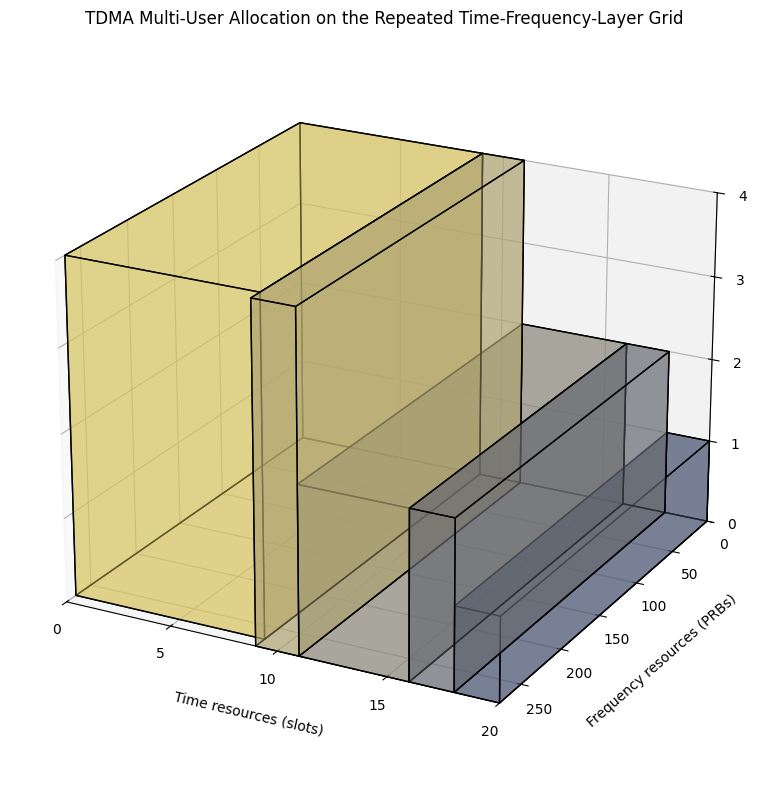

In [9]:
schedule = [
    {
        "user_id": int(row["user_id"]),
        "n_prb": int(row["n_prb"]),
        "n_slots": int(row["n_slots"]),
        "layers": int(row["layers"]),
        "mcs": int(row["mcs"]),
        "pa_name": str(row["pa_name"]),
        "p_dc_active_w": float(row["p_dc_active_w"]),
    }
    for row in sorted(best_schedule["rows"], key=lambda item: int(item["user_id"]))
]

total_prbs = int(max(row["n_prb"] for row in schedule))
total_slots = int(joint_search_result["repeated_period_slots"])
frame_slots = int(joint_search_result["frame_slots"])
max_layers = int(scenario.system_cfg["n_tx_chains"])

color_levels = np.linspace(0.25, 0.85, len(schedule))
user_colors = [colors.to_hex(plt.cm.cividis(level)) for level in color_levels[::-1]]
for row, color in zip(schedule, user_colors):
    row["color"] = color
    row["outline_color"] = color

slot_cursor = 0
for row in schedule:
    row["slot_start"] = slot_cursor
    row["slot_end"] = slot_cursor + row["n_slots"]
    slot_cursor += row["n_slots"]

unused_resource_blocks = []
for row in schedule:
    unused_prbs = total_prbs - row["n_prb"]
    if unused_prbs > 0:
        unused_resource_blocks.append(
            {
                "x": row["n_prb"],
                "y": row["slot_start"],
                "width": unused_prbs,
                "height": row["n_slots"],
            }
        )

if slot_cursor < total_slots:
    unused_resource_blocks.append(
        {
            "x": 0,
            "y": slot_cursor,
            "width": total_prbs,
            "height": total_slots - slot_cursor,
        }
    )

window_boundaries = list(range(frame_slots, total_slots, frame_slots))


def add_time_frequency_overlays(ax):
    for boundary in window_boundaries:
        ax.axhline(boundary, color="#9e9e9e", linewidth=1.2, linestyle=":")

    for block in unused_resource_blocks:
        unused_rect = patches.Rectangle(
            (block["x"], block["y"]),
            block["width"],
            block["height"],
            fill=False,
            edgecolor="black",
            linewidth=2.4,
            linestyle="--",
        )
        ax.add_patch(unused_rect)

    for row in sorted(schedule, key=lambda item: int(item["user_id"]), reverse=True):
        rect = patches.Rectangle(
            (0, row["slot_start"]),
            row["n_prb"],
            row["n_slots"],
            fill=False,
            edgecolor=row["outline_color"],
            linewidth=3.0,
        )
        ax.add_patch(rect)

    legend_handles = [
        patches.Patch(
            facecolor="none",
            edgecolor=row["outline_color"],
            linewidth=3.0,
            label=f"User {row['user_id']} allocation",
        )
        for row in schedule
    ]
    legend_handles.append(
        patches.Patch(
            facecolor="none",
            edgecolor="black",
            linewidth=2.4,
            linestyle="--",
            label="Unused resources",
        )
    )
    if window_boundaries:
        legend_handles.append(
            patches.Patch(
                facecolor="none",
                edgecolor="#9e9e9e",
                linewidth=1.2,
                linestyle=":",
                label="Repeated frame boundary",
            )
        )
    ax.legend(handles=legend_handles, loc="upper left", bbox_to_anchor=(1.21, 1.0), frameon=True)


def cuboid(ax, x, y, z, dx, dy, dz, color):
    vertices = np.array(
        [
            [x, y, z],
            [x + dx, y, z],
            [x + dx, y + dy, z],
            [x, y + dy, z],
            [x, y, z + dz],
            [x + dx, y, z + dz],
            [x + dx, y + dy, z + dz],
            [x, y + dy, z + dz],
        ]
    )

    faces = [
        [vertices[i] for i in [0, 1, 2, 3]],
        [vertices[i] for i in [4, 5, 6, 7]],
        [vertices[i] for i in [0, 1, 5, 4]],
        [vertices[i] for i in [2, 3, 7, 6]],
        [vertices[i] for i in [1, 2, 6, 5]],
        [vertices[i] for i in [0, 3, 7, 4]],
    ]

    poly = Poly3DCollection(faces, facecolors=color, edgecolor="black", alpha=0.45)
    ax.add_collection3d(poly)


fig = plt.figure(figsize=(13, 8))
ax = fig.add_subplot(111, projection="3d")

for row in schedule:
    cuboid(
        ax,
        row["slot_start"],
        0,
        0,
        row["n_slots"],
        row["n_prb"],
        row["layers"],
        row["color"],
    )

for boundary in window_boundaries:
    ax.plot([boundary, boundary], [0, total_prbs], [0, 0], color="#9e9e9e", linestyle=":", linewidth=1.2)

ax.set_xlabel("Time resources (slots)", labelpad=12)
ax.set_ylabel("Frequency resources (PRBs)", labelpad=14)
ax.zaxis.set_rotate_label(False)
ax.set_zlabel("Spatial layers", rotation=90, labelpad=18)
ax.set_xlim(0, total_slots)
ax.set_ylim(total_prbs, 0)
ax.set_zlim(0, max_layers)
ax.set_xticks(np.arange(0, total_slots + 1, max(1, frame_slots // 4)))
ax.set_yticks(np.arange(0, total_prbs + 1, 50))
ax.set_zticks(np.arange(0, max_layers + 1, 1))
ax.set_title("TDMA Multi-User Allocation on the Repeated Time-Frequency-Layer Grid")
ax.view_init(elev=22, azim=-62)
plt.tight_layout()
plt.show()


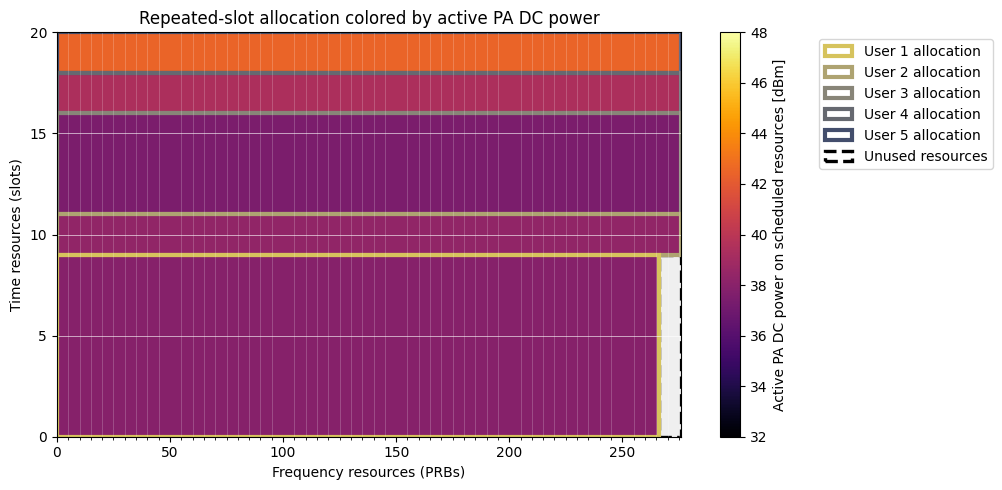

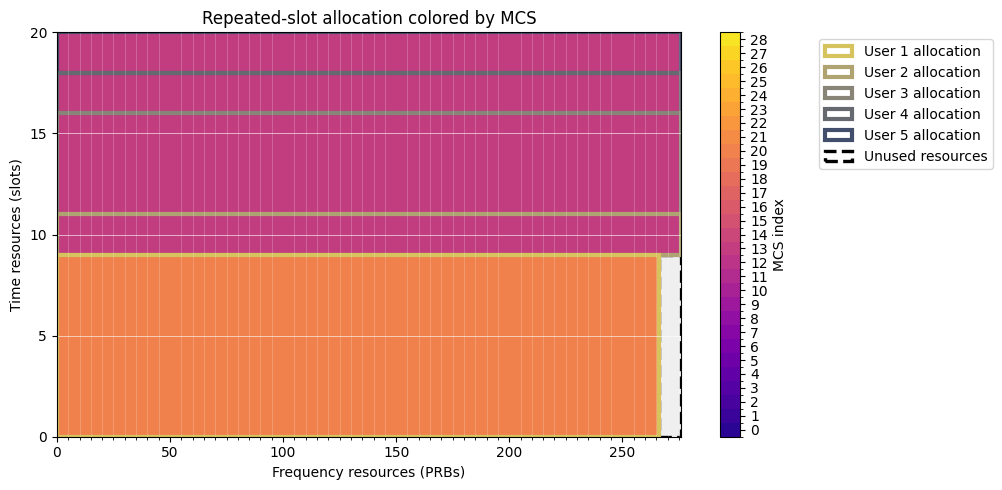

In [10]:
power_slot_grid_w = np.full((total_slots, total_prbs), np.nan)
for row in schedule:
    power_slot_grid_w[row["slot_start"]:row["slot_end"], :row["n_prb"]] = row["p_dc_active_w"]

power_slot_grid_dbm = 10.0 * np.log10(power_slot_grid_w * 1e3)
active_power_dbm = power_slot_grid_dbm[np.isfinite(power_slot_grid_dbm)]

power_cmap = plt.cm.inferno.copy()
power_cmap.set_bad(color="#efefef")

vmin = float(np.floor(active_power_dbm.min()) - 5)
vmax = float(np.ceil(active_power_dbm.max()) + 5)
if np.isclose(vmin, vmax):
    vmax = vmin + 1.0

fig, ax = plt.subplots(figsize=(12, 5))
im = ax.imshow(
    power_slot_grid_dbm,
    origin="lower",
    aspect="auto",
    interpolation="nearest",
    cmap=power_cmap,
    extent=(0, total_prbs, 0, total_slots),
    vmin=vmin,
    vmax=vmax,
)

cbar = plt.colorbar(im, ax=ax)
cbar.set_label("Active PA DC power on scheduled resources [dBm]")
ax.set_xlabel("Frequency resources (PRBs)")
ax.set_ylabel("Time resources (slots)")
ax.set_title("Repeated-slot allocation colored by active PA DC power")
add_time_frequency_overlays(ax)
ax.set_xticks(np.arange(0, total_prbs + 1, 50))
ax.set_xticks(np.arange(0, total_prbs + 1, 5), minor=True)
ax.set_yticks(np.arange(0, total_slots + 1, max(1, frame_slots // 4)))
ax.grid(which="minor", axis="x", linewidth=0.4, color="white", alpha=0.35)
ax.grid(which="major", axis="y", linewidth=0.7, color="white", alpha=0.6)
plt.tight_layout(rect=(0, 0, 0.84, 1))
plt.show()

mcs_grid = np.full((total_slots, total_prbs), np.nan)
for row in schedule:
    mcs_grid[row["slot_start"]:row["slot_end"], :row["n_prb"]] = row["mcs"]

mcs_levels = np.arange(0, 29)
mcs_cmap = colors.ListedColormap(plt.cm.plasma(np.linspace(0.05, 0.95, len(mcs_levels))))
mcs_cmap.set_bad(color="#efefef")
mcs_norm = colors.BoundaryNorm(np.arange(-0.5, 29.5, 1.0), mcs_cmap.N)

fig, ax = plt.subplots(figsize=(12, 5))
im = ax.imshow(
    mcs_grid,
    origin="lower",
    aspect="auto",
    interpolation="nearest",
    cmap=mcs_cmap,
    norm=mcs_norm,
    extent=(0, total_prbs, 0, total_slots),
)

cbar = plt.colorbar(im, ax=ax)
cbar.set_ticks(mcs_levels)
cbar.set_label("MCS index")
ax.set_xlabel("Frequency resources (PRBs)")
ax.set_ylabel("Time resources (slots)")
ax.set_title("Repeated-slot allocation colored by MCS")
add_time_frequency_overlays(ax)
ax.set_xticks(np.arange(0, total_prbs + 1, 50))
ax.set_xticks(np.arange(0, total_prbs + 1, 5), minor=True)
ax.set_yticks(np.arange(0, total_slots + 1, max(1, frame_slots // 4)))
ax.grid(which="minor", axis="x", linewidth=0.4, color="white", alpha=0.35)
ax.grid(which="major", axis="y", linewidth=0.7, color="white", alpha=0.6)
plt.tight_layout(rect=(0, 0, 0.84, 1))
plt.show()


## 9. Validation


In [11]:
sanity_scenarios = {
    "identical_users": [
        dict(user_id=0, distance_m=150.0, required_rate_bps=30e6),
        dict(user_id=1, distance_m=150.0, required_rate_bps=30e6),
    ],
    "near_far": [
        dict(user_id=0, distance_m=100.0, required_rate_bps=20e6),
        dict(user_id=1, distance_m=200.0, required_rate_bps=50e6),
    ],
    "high_low_rate": [
        dict(user_id=0, distance_m=150.0, required_rate_bps=50e6),
        dict(user_id=1, distance_m=150.0, required_rate_bps=20e6),
    ],
    "three_user_smoke": [
        dict(user_id=0, distance_m=100.0, required_rate_bps=30e6),
        dict(user_id=1, distance_m=150.0, required_rate_bps=40e6),
        dict(user_id=2, distance_m=200.0, required_rate_bps=50e6),
    ],
}


def enumerate_two_user_joint_schedules_exhaustive(
    user_candidate_spaces,
    repeated_period_slots,
    pa_catalog,
    n_tx_chains,
    switch_policy,
):
    user0_id, user1_id = sorted(user_candidate_spaces)
    rows0 = user_candidate_spaces[user0_id].to_dict("records")
    rows1 = user_candidate_spaces[user1_id].to_dict("records")

    candidate_rows = []
    best_rank = (np.inf, np.inf, np.inf)
    best_schedule_local = None
    for row0 in rows0:
        for row1 in rows1:
            slot_total = int(row0["n_slots"] + row1["n_slots"])
            if slot_total > int(repeated_period_slots):
                continue

            schedule_result = evaluate_schedule_rows(
                selected_rows=[row0, row1],
                repeated_period_slots=repeated_period_slots,
                pa_catalog=pa_catalog,
                n_tx_chains=n_tx_chains,
                switch_policy=switch_policy,
            )
            candidate_rows.append(
                {
                    "schedule_id": int(len(candidate_rows) + 1),
                    "slot_total": int(schedule_result["slot_total"]),
                    "alpha_total_frame": float(schedule_result["alpha_total_frame"]),
                    "unused_slots": int(schedule_result["unused_slots"]),
                    "unused_frame_time": float(schedule_result["unused_frame_time"]),
                    "total_rate_bps": float(schedule_result["total_rate_bps"]),
                    "schedule_p_dc_total_avg_frame_w": float(schedule_result["schedule_p_dc_total_avg_frame_w"]),
                    "schedule_p_rf_out_total_avg_frame_w": float(schedule_result["schedule_p_rf_out_total_avg_frame_w"]),
                }
            )

            candidate_rank = schedule_rank(
                schedule_result["schedule_p_dc_total_avg_frame_w"],
                slot_total,
                schedule_result["total_rate_bps"],
            )
            if candidate_rank < best_rank:
                best_rank = candidate_rank
                best_schedule_local = schedule_result

    joint_df_exhaustive = pd.DataFrame(candidate_rows)
    if not joint_df_exhaustive.empty:
        joint_df_exhaustive = joint_df_exhaustive.sort_values(
            ["schedule_p_dc_total_avg_frame_w", "slot_total", "total_rate_bps"],
            ascending=[True, True, False],
        ).reset_index(drop=True)
    return {
        "joint_df": joint_df_exhaustive,
        "best_schedule": best_schedule_local,
    }


def validate_scheduler_result(joint_search_result, scenario_table):
    target_rate_map = {
        int(row.user_id): float(row.required_rate_bps)
        for row in scenario_table.itertuples(index=False)
    }
    best_rows = joint_search_result["best_schedule"]["rows"]
    alpha_sum_frame = float(sum(row_active_frame_share(row) for row in best_rows))
    schedule_p_dc_sum = float(
        sum(pa_row["pa_p_dc_total_avg_frame_w"] for pa_row in joint_search_result["best_schedule"]["pa_summaries"])
    )
    rf_output_power_sum = float(sum(row_p_rf_out_avg_frame_w(row) for row in best_rows))
    rate_sum = float(sum(row_rate_avg_frame_bps(row) for row in best_rows))
    returned_user_ids = {int(row["user_id"]) for row in best_rows}
    expected_user_ids = set(target_rate_map)

    return {
        "meets_rate_targets": all(
            row_rate_avg_frame_bps(row) + 1e-9 >= target_rate_map[int(row["user_id"])]
            for row in best_rows
        ),
        "alpha_sum_frame_within_budget": alpha_sum_frame <= 1.0 + 1e-12,
        "schedule_p_dc_consistent": np.isclose(
            schedule_p_dc_sum,
            float(joint_search_result["best_schedule"]["schedule_p_dc_total_avg_frame_w"]),
        ),
        "schedule_p_rf_consistent": np.isclose(
            rf_output_power_sum,
            float(joint_search_result["best_schedule"]["schedule_p_rf_out_total_avg_frame_w"]),
        ),
        "total_rate_consistent": np.isclose(
            rate_sum,
            float(joint_search_result["best_schedule"]["total_rate_bps"]),
        ),
        "user_coverage_complete": returned_user_ids == expected_user_ids,
    }


def run_validation_scenario(scenario_users, switch_policy):
    scenario_table = pd.DataFrame(scenario_users).sort_values("user_id").reset_index(drop=True)
    scenario_local = build_multi_user_tdma_scenario(scenario_table)
    study_result_local = run_multi_user_tdma_scenario(
        scenario_local,
        outer_parallel=NOTEBOOK_OUTER_PARALLEL,
        max_workers=NOTEBOOK_MAX_WORKERS,
    )
    joint_search_result_local = run_joint_schedule_search(
        scenario_local,
        study_result_local,
        switch_policy=switch_policy,
    )
    return scenario_local, study_result_local, joint_search_result_local


def compare_switch_policies(scenario_name, scenario_users):
    rows = []
    for policy in [PASwitchPolicy.STANDBY, PASwitchPolicy.HARD_OFF]:
        _, study_result_local, joint_search_result_local = run_validation_scenario(
            scenario_users,
            switch_policy=policy,
        )
        rows.append(
            {
                "scenario": scenario_name,
                "switch_policy": policy.value,
                "repeated_frames": int(study_result_local.repeated_frames),
                "schedule_p_dc_total_avg_frame_w": float(
                    joint_search_result_local["best_schedule"]["schedule_p_dc_total_avg_frame_w"]
                ),
                "schedule_p_rf_out_total_avg_frame_w": float(
                    joint_search_result_local["best_schedule"]["schedule_p_rf_out_total_avg_frame_w"]
                ),
                "total_rate_mbps": float(joint_search_result_local["best_schedule"]["total_rate_bps"]) / 1e6,
            }
        )
    return pd.DataFrame(rows)


validation_rows = []
comparison_rows = []
for scenario_name, scenario_users in sanity_scenarios.items():
    scenario_local, study_result_local, joint_search_result_local = run_validation_scenario(
        scenario_users,
        switch_policy=switch_policy,
    )
    checks = validate_scheduler_result(joint_search_result_local, scenario_local.user_table)
    validation_row = {
        "scenario": scenario_name,
        **checks,
    }

    if len(scenario_users) == 2:
        exhaustive = enumerate_two_user_joint_schedules_exhaustive(
            user_candidate_spaces=study_result_local.user_candidate_spaces,
            repeated_period_slots=study_result_local.repeated_period_slots,
            pa_catalog=scenario_local.pa_catalog,
            n_tx_chains=int(scenario_local.system_cfg["n_tx_chains"]),
            switch_policy=switch_policy,
        )
        validation_row["matches_exhaustive_objective"] = np.isclose(
            float(exhaustive["best_schedule"]["schedule_p_dc_total_avg_frame_w"]),
            float(joint_search_result_local["best_schedule"]["schedule_p_dc_total_avg_frame_w"]),
        )

    validation_rows.append(validation_row)
    comparison_rows.append(compare_switch_policies(scenario_name, scenario_users))

validation_df = pd.DataFrame(validation_rows)
policy_comparison_df = pd.concat(comparison_rows, ignore_index=True)
display(validation_df)
display(policy_comparison_df)


,scenario,meets_rate_targets,alpha_sum_frame_within_budget,schedule_p_dc_consistent,schedule_p_rf_consistent,total_rate_consistent,user_coverage_complete,matches_exhaustive_objective
0,identical_users,True,True,True,True,True,True,True
1,near_far,True,True,True,True,True,True,True
2,high_low_rate,True,True,True,True,True,True,True
3,three_user_smoke,True,True,True,True,True,True,NaN


,scenario,switch_policy,repeated_frames,schedule_p_dc_total_avg_frame_w,schedule_p_rf_out_total_avg_frame_w,total_rate_mbps
0,identical_users,standby,1,3.064470,0.155602,60.859192
1,identical_users,hard_off,1,1.012720,0.155602,60.859192
2,near_far,standby,1,3.305064,0.229127,75.059988
3,near_far,hard_off,1,1.581611,0.254714,71.002391
4,high_low_rate,standby,1,3.103240,0.167324,74.908378
5,high_low_rate,hard_off,1,1.211862,0.221757,70.866184
6,three_user_smoke,standby,1,3.613407,0.331900,135.846858
7,three_user_smoke,hard_off,1,2.360252,0.422348,121.649645
